# Data Cleaning Assignment

**Dataset:** Healthcare Patient Records  
**Objective:** Clean, validate, transform, and prepare the healthcare dataset for analysis using Python and Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

file_name = 'healthcare_data_cleaning_dataset.csv'
possible_paths = [Path(file_name), Path('/content') / file_name, Path('/mnt/data') / file_name]
file_path = next((p for p in possible_paths if p.exists()), None)

if file_path is None:
    from google.colab import files
    uploaded = files.upload()
    file_path = Path(next(iter(uploaded)))

df = pd.read_csv(file_path)
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], errors='coerce')
print('Dataset loaded successfully.')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully.
Shape: (5100, 9)


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


## Q1. Missing Data Identification

**Scenario:** The hospital suspects incomplete patient records.

**Task:**
- Identify missing values in each column.
- Calculate percentage of missing data.

### Solution

In [2]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Values': missing_count, 'Missing Percentage (%)': missing_percentage})
print(missing_summary)


                    Missing Values  Missing Percentage (%)
Patient_ID                       0                    0.00
Age                            600                   11.76
Gender                           0                    0.00
City                             0                    0.00
Diagnosis                        0                    0.00
Hospital_Visits                  0                    0.00
Treatment_Cost                 593                   11.63
Insurance_Coverage               0                    0.00
Admission_Date                   0                    0.00


The table above identifies the number and percentage of missing values in every column.

## Q2. Handling Missing Age

**Scenario:** Age is critical for medical analysis, but some values are missing.

**Task:**
- Replace missing Age values with an appropriate method.
- Justify your choice (mean/median).

### Solution

In [3]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()
print(f'Age mean: {age_mean:.2f}')
print(f'Age median: {age_median:.2f}')

# Median is robust to extreme/invalid age values and is therefore preferred here.
df['Age'] = df['Age'].fillna(age_median)
print('Missing Age values after imputation:', df['Age'].isnull().sum())

Age mean: 49.60
Age median: 50.00
Missing Age values after imputation: 0


**Justification:** Median imputation is used because it is less affected by unusually high or low values than the mean. This makes it a safer measure of central tendency for Age before the later validity check.

## Q3. Handling Missing Treatment Cost

**Scenario:** Treatment cost is highly skewed due to expensive treatments.

**Task:**
- Handle missing Treatment_Cost values.
- Choose the correct imputation method and explain why.

### Solution

In [4]:
cost_median = df['Treatment_Cost'].median()
print(f'Treatment_Cost median: {cost_median:.2f}')

df['Treatment_Cost'] = df['Treatment_Cost'].fillna(cost_median)
print('Missing Treatment_Cost values after imputation:', df['Treatment_Cost'].isnull().sum())

Treatment_Cost median: 24797.00
Missing Treatment_Cost values after imputation: 0


**Justification:** The median is used because Treatment_Cost is skewed. Unlike the mean, the median is resistant to very expensive treatments and therefore gives a more representative replacement value.

## Q4. Duplicate Patient Records

**Scenario:** Some patient records were entered multiple times.

**Task:**
- Identify duplicate rows.
- Remove duplicates.
- Compare dataset size before and after.

### Solution

In [5]:
rows_before = len(df)
duplicate_rows = df.duplicated().sum()
print('Duplicate rows found:', duplicate_rows)

df = df.drop_duplicates().copy()
rows_after = len(df)
print('Rows before removing duplicates:', rows_before)
print('Rows after removing duplicates:', rows_after)
print('Rows removed:', rows_before - rows_after)

Duplicate rows found: 99
Rows before removing duplicates: 5100
Rows after removing duplicates: 5001
Rows removed: 99


Duplicate records are removed so that repeated patient entries do not bias counts, averages, or other analysis.

## Q5. Invalid Age Values (Data Quality Check)

**Scenario:** Some patients have unrealistic age values (e.g., >100 or <0).

**Task:**
- Detect such records.
- Decide whether to remove or correct them.

### Solution

In [6]:
invalid_age_mask = (df['Age'] < 0) | (df['Age'] > 100)
invalid_age_records = df.loc[invalid_age_mask]
print('Invalid age records:', len(invalid_age_records))
display(invalid_age_records.head(10))

# Since the true ages are unknown, replace invalid ages with the median of valid ages.
valid_age_median = df.loc[df['Age'].between(0, 100), 'Age'].median()
df.loc[invalid_age_mask, 'Age'] = valid_age_median
print(f'Valid-age median used for correction: {valid_age_median:.2f}')
print('Invalid ages remaining:', ((df['Age'] < 0) | (df['Age'] > 100)).sum())

Invalid age records: 0


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date


Valid-age median used for correction: 50.00
Invalid ages remaining: 0


**Decision:** The records are retained, but impossible ages are corrected using the median of valid ages. Removing entire rows would discard otherwise useful patient information, while guessing an exact age would be unjustified.

## Q6. Outlier Detection (Treatment Cost)

**Scenario:** Extreme treatment costs are affecting analysis.

**Task:**
- Detect outliers using IQR method.
- Display number of outliers.

### Solution

In [7]:
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)
print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
print('Number of Treatment_Cost outliers:', outlier_mask.sum())

Q1: 13766.00
Q3: 36542.00
IQR: 22776.00
Lower bound: -20398.00
Upper bound: 70706.00
Number of Treatment_Cost outliers: 50


The IQR method flags observations outside Q1 − 1.5×IQR and Q3 + 1.5×IQR as outliers.

## Q7. Outlier Treatment

**Scenario:** The business team wants to retain all records.

**Task:**
- Apply capping (Winsorization) on Treatment_Cost.
- Use 5th and 95th percentile.

### Solution

In [8]:
p05 = df['Treatment_Cost'].quantile(0.05)
p95 = df['Treatment_Cost'].quantile(0.95)
print(f'5th percentile: {p05:.2f}')
print(f'95th percentile: {p95:.2f}')

# Keep a pre-capping copy for comparison.
df['Treatment_Cost_Original'] = df['Treatment_Cost']
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=p05, upper=p95)
print('Minimum cost after capping:', df['Treatment_Cost'].min())
print('Maximum cost after capping:', df['Treatment_Cost'].max())

5th percentile: 3238.00
95th percentile: 47948.00
Minimum cost after capping: 3238.0
Maximum cost after capping: 47948.0


Winsorization retains every record while limiting the influence of extreme costs. Values below the 5th percentile are capped at P5 and values above the 95th percentile are capped at P95.

## Q8. Transformation

**Scenario:** Treatment cost is highly skewed.

**Task:**
- Apply log transformation.
- Create a new column.
- Compare before vs after distribution.

### Solution

Skewness before log transformation: 0.055
Skewness after log transformation: -1.035


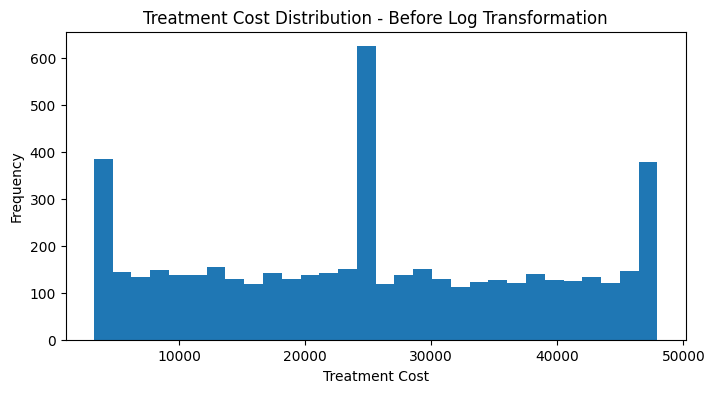

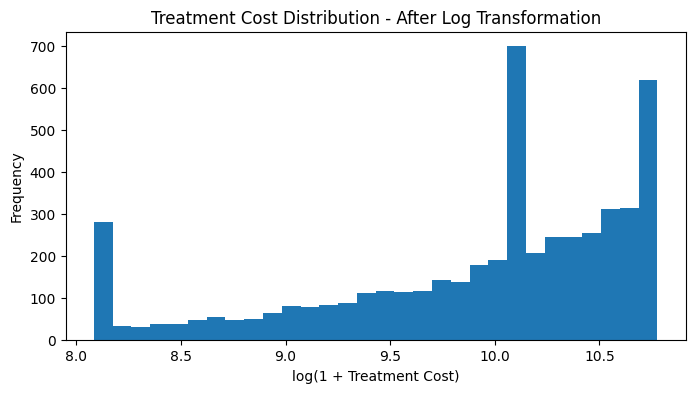

In [9]:
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])

print('Skewness before log transformation:', round(df['Treatment_Cost'].skew(), 3))
print('Skewness after log transformation:', round(df['Treatment_Cost_Log'].skew(), 3))

plt.figure(figsize=(8, 4))
plt.hist(df['Treatment_Cost'], bins=30)
plt.title('Treatment Cost Distribution - Before Log Transformation')
plt.xlabel('Treatment Cost')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['Treatment_Cost_Log'], bins=30)
plt.title('Treatment Cost Distribution - After Log Transformation')
plt.xlabel('log(1 + Treatment Cost)')
plt.ylabel('Frequency')
plt.show()

A new `Treatment_Cost_Log` column is created with `log1p()`. Comparing skewness and histograms shows how the transformation changes the shape of the distribution.

## Q9. Time-Based Missing Handling

**Scenario:** Admission dates should follow a logical sequence.

**Task:**
- Sort data by Admission_Date.
- Apply forward fill or backward fill where appropriate.
- Justify your choice.

### Solution

In [10]:
df = df.sort_values('Admission_Date').reset_index(drop=True)
missing_dates_before = df['Admission_Date'].isnull().sum()

# Forward fill is appropriate after chronological sorting because a missing value
# is filled from the most recently available preceding observation.
df['Admission_Date'] = df['Admission_Date'].ffill()
missing_dates_after = df['Admission_Date'].isnull().sum()

print('Missing Admission_Date values before fill:', missing_dates_before)
print('Missing Admission_Date values after forward fill:', missing_dates_after)
print('Dates sorted in ascending order:', df['Admission_Date'].is_monotonic_increasing)
df[['Patient_ID', 'Admission_Date']].head(10)

Missing Admission_Date values before fill: 0
Missing Admission_Date values after forward fill: 0
Dates sorted in ascending order: True


,Patient_ID,Admission_Date
0,19591,2023-01-01
1,10896,2023-01-01
2,19262,2023-01-01
3,12843,2023-01-01
4,17230,2023-01-01
5,13863,2023-01-01
6,18716,2023-01-01
7,19175,2023-01-01
8,10959,2023-01-01
9,14612,2023-01-01


**Justification:** After sorting chronologically, forward fill is chosen because it uses the most recent known date for a subsequent missing entry and avoids using future information. In this dataset, the output also verifies whether any date values actually required filling.

## Final Cleaned Dataset

The cleaned dataset is checked and exported for further analysis.

In [11]:
print('Final dataset shape:', df.shape)
print('Total missing values remaining:', int(df.isnull().sum().sum()))
print('Duplicate rows remaining:', int(df.duplicated().sum()))
print('Invalid ages remaining:', int(((df['Age'] < 0) | (df['Age'] > 100)).sum()))

df.to_csv('healthcare_data_cleaned.csv', index=False)
df.head()

Final dataset shape: (5001, 11)
Total missing values remaining: 0
Duplicate rows remaining: 0
Invalid ages remaining: 0


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date,Treatment_Cost_Original,Treatment_Cost_Log
0,19591,91.0,Male,Chennai,Asthma,3,32149.0,0,2023-01-01,32149.000000,10.378168
1,10896,88.0,Female,Chennai,COVID-19,3,47948.0,1,2023-01-01,199702.965333,10.777893
2,19262,50.0,Female,Hyderabad,Asthma,9,24797.0,0,2023-01-01,24797.000000,10.118518
3,12843,89.0,Female,Bangalore,COVID-19,14,46469.0,1,2023-01-01,46469.000000,10.746562
4,17230,41.0,Male,Bangalore,Hypertension,18,12398.0,0,2023-01-01,12398.000000,9.425371
